<a href="https://colab.research.google.com/github/khushalbokde105/EE_machine_learning/blob/main/task10%2CEE541.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None
    def forward(self, input):
        pass
    def backward(self,output_gradient, learning_rate):
        pass

In [ ]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)
    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias
    def backward(self, output_gradient, learning_rate):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)
        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient
        return input_gradient

In [ ]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))
def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)


In [ ]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime
    def forward(self, input):
        self.input = input
        return self.activation(self.input)
    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [ ]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)
        def tanh_prime(x):
            return 1- np.tanh(x) ** 2
        super().__init__(tanh, tanh_prime)
class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))
        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1-s)
        super().__init__(sigmoid, sigmoid_prime)

In [ ]:
import math

In [ ]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x
        def linear_prime(x):
            return 1
        super().__init__(linear, linear_prime)

In [ ]:
X = np.linspace(-3, 3, 61)
Y = [math.sin(p) for p in X]
network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]
epochs = 50
learning_rate = 0.1
errorlist = []
for e in range(epochs):
    error = 0
    for x, y in zip(X, Y):
        output = x
        for layer in network:
            output = layer.forward(output)
        error += mse(y, output)
        grad = mse_prime(y, output)
        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(X)
    print(f"{e + 1}/{epochs}, error={error}")
    errorlist.append(error)

1/50, error=0.12479979370840924
2/50, error=0.027359270739918538
3/50, error=0.00519587362142653
4/50, error=0.04424716261698607
5/50, error=0.013852204338885468
6/50, error=0.04235889347584598
7/50, error=0.028655675737483045
8/50, error=0.025552877032753475
9/50, error=0.015047501411085707
10/50, error=0.008103281220168068
11/50, error=0.003655501105304745
12/50, error=0.0020728453422780052
13/50, error=0.0024746193542727114
14/50, error=0.002009402230341224
15/50, error=0.0031823146692657196
16/50, error=0.0010516826888285855
17/50, error=0.001574765224967089
18/50, error=0.003371727646856521
19/50, error=0.0050272021887397865
20/50, error=0.006921883324777024
21/50, error=0.008545409861527492
22/50, error=0.009906399428258406
23/50, error=0.011016573191801602
24/50, error=0.013401447858107924
25/50, error=0.020174908963417
26/50, error=0.01238303386674821
27/50, error=0.009438135179646841
28/50, error=0.03618736849133198
29/50, error=0.05462982760770272
30/50, error=0.0073030295455

In [ ]:
actual_Y = []
for x in X:
    output = x
    for layer in network:
        output = layer.forward(output)
    actual_Y.append(output[0])
print(output)

[[0.20679616]]


In [ ]:
import matplotlib.pyplot as plt

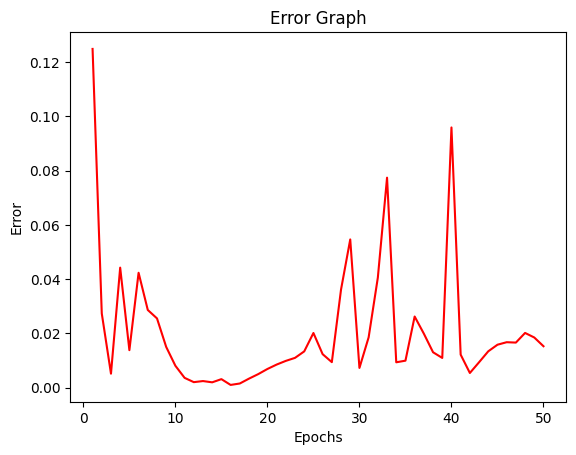

In [ ]:
plt.plot(range(1, epochs + 1), errorlist, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
def preprocess_data(x, y, limit):
    x = x.reshape(x.shape[0], 28 * 28, 1)
    x = x.astype("float32") / 255
    y = to_categorical(y)
    y = y.reshape(y.shape[0], 10, 1)
    return x[:limit], y[:limit]

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]
epochs = 50
learning_rate = 0.1
errorlist = []
for e in range(epochs):
    error = 0
    for x, y in zip(x_train, y_train):
        output = x
        for layer in network:
            output = layer.forward(output)
        error += mse(y, output)
        grad = mse_prime(y, output)
        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x_train)
    print(f"{e + 1}/{epochs}, error={error}")
    errorlist.append(error)

1/50, error=0.10552466207250748
2/50, error=0.08452266183901225
3/50, error=0.07819023920669393
4/50, error=0.07291988511281357
5/50, error=0.06854187971122946
6/50, error=0.06295227576151292
7/50, error=0.05668577148725808
8/50, error=0.04995035053943434
9/50, error=0.04560478882295852
10/50, error=0.04285402817243108
11/50, error=0.04091153875281954
12/50, error=0.03943927361665875
13/50, error=0.038253779208468355
14/50, error=0.0372667530940738
15/50, error=0.03643073756538292
16/50, error=0.03571201509503035
17/50, error=0.03508546887706646
18/50, error=0.03453193927790859
19/50, error=0.03403733082633158
20/50, error=0.03359056925611438
21/50, error=0.03318244024290023
22/50, error=0.03280507954330212
23/50, error=0.032452455961053124
24/50, error=0.03212081130369279
25/50, error=0.03180857666712891
26/50, error=0.031515597254795975
27/50, error=0.031241553124531408
28/50, error=0.030985093198626107
29/50, error=0.030744268168511866
30/50, error=0.03051705841378892
31/50, error=0

In [ ]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

In [ ]:
!pip install simple_colors
import simple_colors

In [ ]:
correct = 0
for x, y in zip(x_test, y_test):
    output = predict(network, x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '\ttrue:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'))
        accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 2 	true: 7
pred: 2 	true: 2
pred: 1 	true: 1
pred: 0 	true: 0
pred: 4 	true: 4
pred: 1 	true: 1
pred: 4 	true: 4
pred: 9 	true: 9
pred: 9 	true: 5
pred: 9 	true: 9
pred: 0 	true: 0
pred: 6 	true: 6
pred: 9 	true: 9
pred: 0 	true: 0
pred: 1 	true: 1
pred: 5 	true: 5
pred: 9 	true: 9
pred: 3 	true: 7
pred: 3 	true: 3
pred: 4 	true: 4
Accuracy: 0.75
Correct: 17


In [ ]:
error = errorlist
X = list(range(1, len(errorlist) + 1))

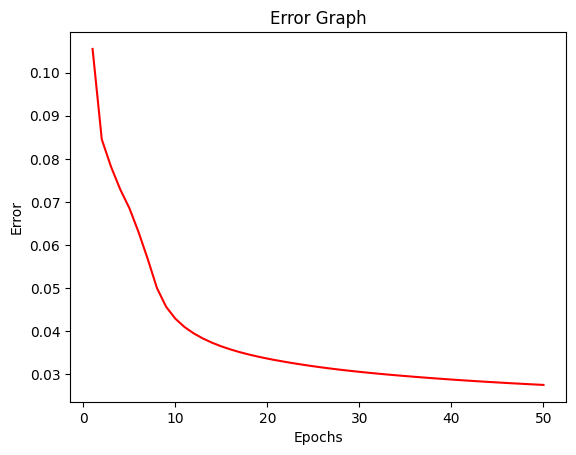

In [ ]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()